# 

c:\Workspace\COIN\ML_HDD\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📦 데이터를 불러오는 중...
✅ 데이터 로드 완료! (Train: (299013, 310), Test: (686901, 310))
🖥️ 하드웨어 가속 상태: 🚀 GPU (사용 가능)
🚫 총 141개의 피처가 JSON 설정에 의해 추가 제외됩니다.
📊 최종 학습 피처 수: 163개


🚀 CV 진행률: 100%|██████████| 5/5 [02:27<00:00, 29.57s/it]



📊 [교차 검증] 평균 PR-AUC: 0.7417
🎯 [최종 테스트] PR-AUC: 0.4062

🏆 상위 20개 피처:
              feature    importance
        smart_197_raw 501241.696679
        smart_187_raw 150561.123058
 total_seeks_28d_asfd  60136.009025
        smart_184_raw  57522.044626
          smart_9_raw  31610.785620
        smart_242_raw  22145.115953
  total_seeks_28d_max  21126.637826
    error_density_14d  20912.575489
   workload_intensity  19053.545163
        smart_241_raw  16944.158720
          total_seeks  16627.529759
     total_seeks_diff  16195.224976
 total_seeks_14d_mean  16079.602655
  total_reads_28d_max  15021.064114
write_stability_ratio  14530.618729
        s242_28d_asfd  12982.771489
         s198_28d_max  11483.507864
         s187_28d_sum  11191.110103
s187_days_since_first  11174.638019
            s241_diff  10889.857153


C:\Users\joon6\AppData\Local\Temp\ipykernel_11104\1690770164.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp.head(10), ax=axes[0], palette='viridis')
C:\Users\joon6\AppData\Local\Temp\ipykernel_11104\1690770164.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp.tail(10), ax=axes[1], palette='magma')
C:\Users\joon6\AppData\Local\Temp\ipykernel_11104\1690770164.py:125: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\joon6\AppData\Local\Temp\ipykernel_11104\1690770164.py:125: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing fro

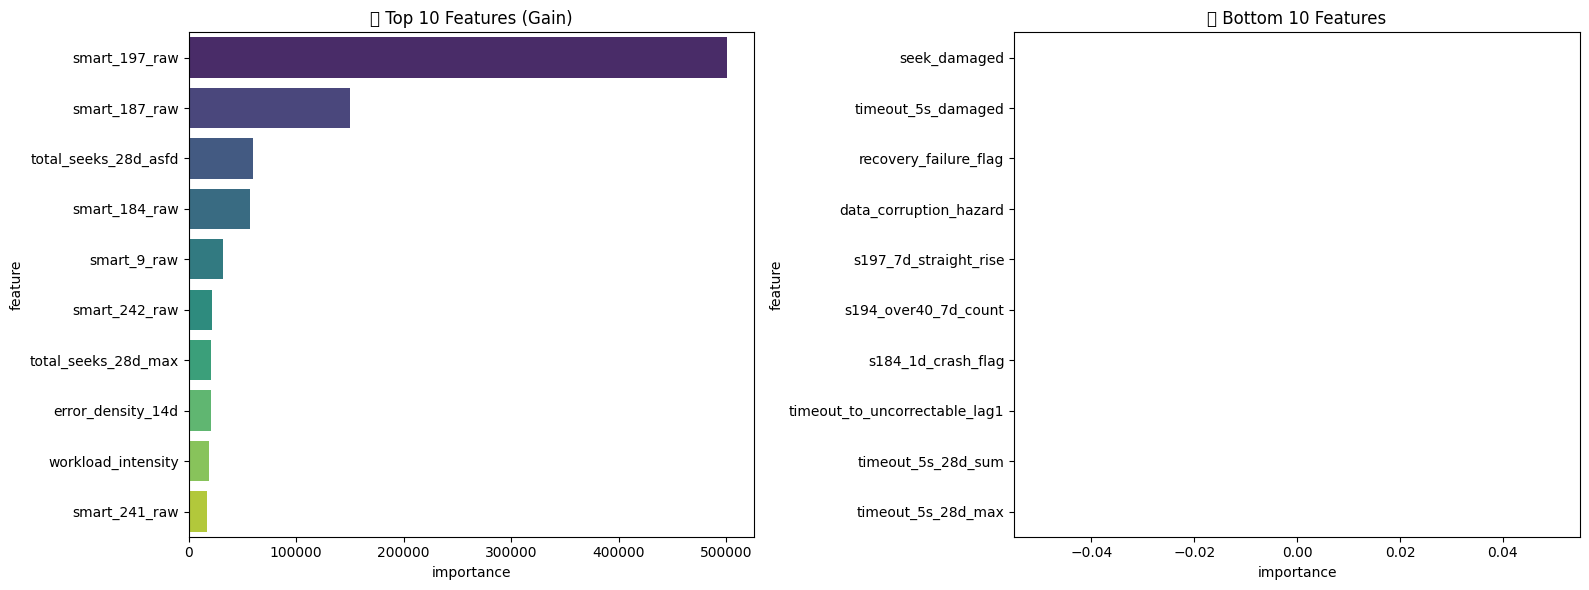


🔮 SHAP 분석 진행 중... (테스트 데이터셋의 기여도 분석)


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import duckdb
import shap
import json
import os
from tqdm.auto import tqdm
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# [추가] 제외 리스트 로드 함수
# ---------------------------------------------------------
def get_exclusion_list(paths):
    """여러 JSON 파일에서 제외할 피처 목록을 합쳐서 반환합니다."""
    exclude_set = set()
    for path in paths:
        if not os.path.exists(path):
            print(f"⚠️ 제외 설정 파일을 찾을 수 없습니다: {path}")
            continue
        with open(path, 'r', encoding='utf-8') as f:
            cfg = json.load(f)
            for key in cfg:
                if isinstance(cfg[key], list):
                    exclude_set.update(cfg[key])
    return list(exclude_set)

# 0. 데이터 경로 및 제외 리스트 설정 (경로 수정됨)
train_path = "../data/rfe_sample_data/rfe_sample_train.parquet"
test_path = "../data/rfe_sample_data/rfe_sample_test.parquet"

REMOVE_LISTS = [
    r'..\config\remove_features_v1.json',
    r'..\config\remove_features_v2.json',
]

print("📦 데이터를 불러오는 중...")
train_df = duckdb.query(f"SELECT * FROM '{train_path}'").df()
test_df = duckdb.query(f"SELECT * FROM '{test_path}'").df()
print(f"✅ 데이터 로드 완료! (Train: {train_df.shape}, Test: {test_df.shape})")

# 1. GPU 인식 여부 확인
has_gpu = False
try:
    lgb.train({'device': 'gpu', 'verbose': -1}, lgb.Dataset(np.zeros((1, 1)), label=[0]))
    has_gpu = True
except:
    has_gpu = False
print(f"🖥️ 하드웨어 가속 상태: {'🚀 GPU (사용 가능)' if has_gpu else '💻 CPU (사용 가능)'}")

# 2. 학습/테스트 데이터 분리 (제외 리스트 적용)
base_drop_cols = [
    'failure', 'date', 'serial_number', 
    's198_damaged', 's187_damaged', 's5_damaged'
]

json_exclude_cols = get_exclusion_list(REMOVE_LISTS)
final_drop_cols = list(set(base_drop_cols + json_exclude_cols))

print(f"🚫 총 {len(json_exclude_cols)}개의 피처가 JSON 설정에 의해 추가 제외됩니다.")

X_train = train_df.drop(columns=final_drop_cols, errors='ignore')
y_train = train_df['failure']

X_test = test_df.drop(columns=final_drop_cols, errors='ignore')
y_test = test_df['failure']

print(f"📊 최종 학습 피처 수: {X_train.shape[1]}개")

# 3. 모델 설정
model = LGBMClassifier(
    objective='binary',
    importance_type='gain', 
    class_weight='balanced',
    max_depth=6,
    num_leaves=40, 
    n_estimators=200, 
    learning_rate=0.07, 
    device='gpu' if has_gpu else 'cpu',
    random_state=42, 
    n_jobs=-1, 
    verbose=-1
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
importances_list = []

# 4. 5-Fold 교차 검증
for train_idx, val_idx in tqdm(list(cv.split(X_train, y_train)), desc="🚀 CV 진행률"):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model.fit(X_fold_train, y_fold_train)
    y_prob = model.predict_proba(X_fold_val)[:, 1]
    cv_scores.append(average_precision_score(y_fold_val, y_prob))
    importances_list.append(model.feature_importances_)

# 5. 테스트 데이터 평가
model.fit(X_train, y_train) 
test_prob = model.predict_proba(X_test)[:, 1]
test_score = average_precision_score(y_test, test_prob)

print(f"\n📊 [교차 검증] 평균 PR-AUC: {np.mean(cv_scores):.4f}")
print(f"🎯 [최종 테스트] PR-AUC: {test_score:.4f}")

# 6. 피처 중요도 정리 및 시각화 (Gain 기반)
feat_imp = pd.DataFrame({
    'feature': X_train.columns, 
    'importance': np.mean(importances_list, axis=0)
}).sort_values(by='importance', ascending=False)

print("\n🏆 상위 20개 피처:")
print(feat_imp.head(20).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='importance', y='feature', data=feat_imp.head(10), ax=axes[0], palette='viridis')
axes[0].set_title("🏆 Top 10 Features (Gain)")
sns.barplot(x='importance', y='feature', data=feat_imp.tail(10), ax=axes[1], palette='magma')
axes[1].set_title("📉 Bottom 10 Features")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. SHAP 분석 (추가된 부분)
# ---------------------------------------------------------
print("\n🔮 SHAP 분석 진행 중... (테스트 데이터셋의 기여도 분석)")
explainer = shap.TreeExplainer(model)
# shap_values 계산 (X_test 전체 또는 일부 샘플링해서 사용 가능)
# 데이터가 너무 크면 shap_values = explainer.shap_values(X_test.sample(2000)) 식으로 조절하세요.
shap_values = explainer.shap_values(X_test)

# SHAP values 처리 (LGBMClassifier의 경우 버전/환경에 따라 리스트 형식이 다를 수 있음)
if isinstance(shap_values, list):
    # 이진 분류에서 [0]은 클래스 0, [1]은 클래스 1(Failure)에 대한 기여도
    sv = shap_values[1]
else:
    sv = shap_values

# 요약 플롯 (기여도 분포)
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot (Test Set)")
shap.summary_plot(sv, X_test, max_display=20)

# 막대 플롯 (절대 중요도)
plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Importance (Absolute)")
shap.summary_plot(sv, X_test, plot_type="bar", max_display=20)
